✓ Saved: fano_failure_mode.png


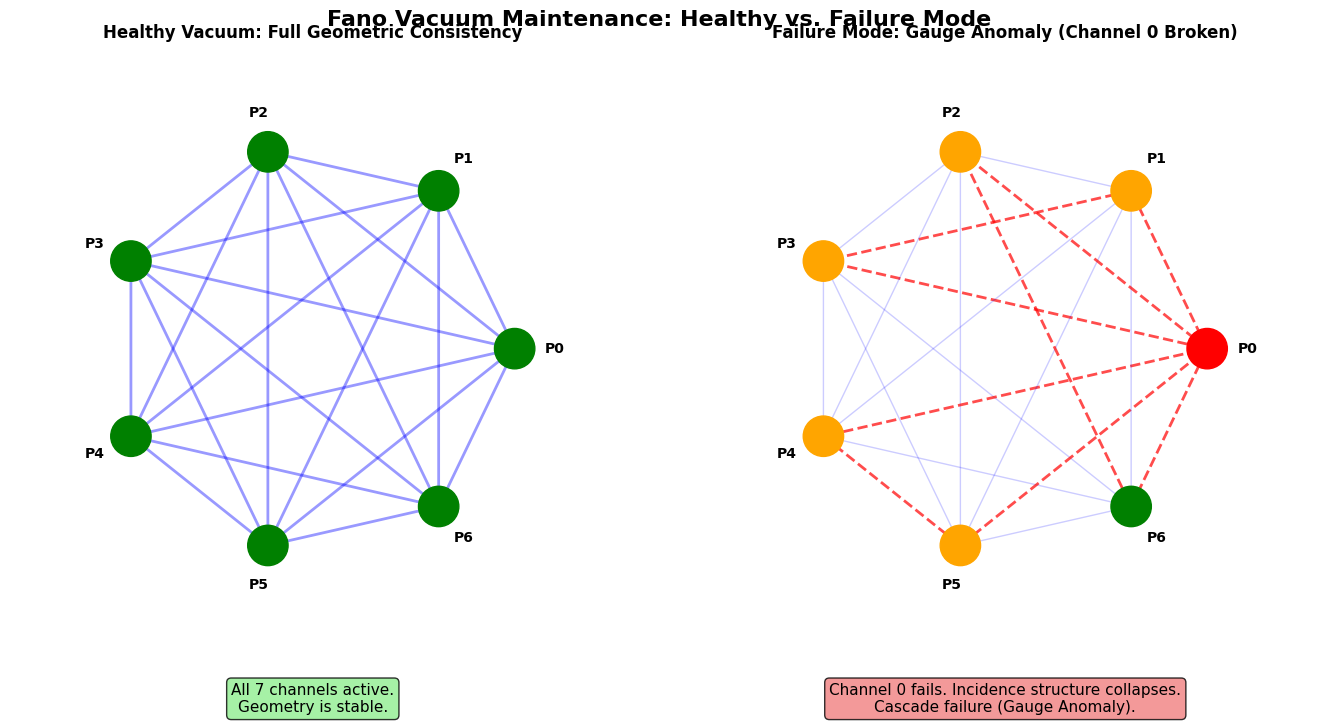

In [ ]:
"""
fano_failure_mode_diagram.py
==============================
Generates the "Failure Mode" diagram showing why the 7 maintenance
channels are load-bearing pillars of the vacuum geometry.
"""

import matplotlib.pyplot as plt
import numpy as np

def plot_fano_failure_mode():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
    fig.suptitle("Fano Vacuum Maintenance: Healthy vs. Failure Mode", fontsize=16, fontweight='bold')

    # Coordinates for a clean topological representation (Circular layout)
    angles = np.linspace(0, 2*np.pi, 7, endpoint=False)
    coords = {i: (np.cos(angles[i]), np.sin(angles[i])) for i in range(7)}

    # Fano lines (triples) - the incidence structure
    lines = [
        (0, 1, 3), (1, 2, 4), (2, 3, 5),
        (3, 4, 6), (4, 5, 0), (5, 6, 1), (6, 0, 2)
    ]

    # =============================================================================
    # Panel 1: Healthy Vacuum
    # =============================================================================
    ax1.set_title("Healthy Vacuum: Full Geometric Consistency", fontsize=12, fontweight='bold')

    # Draw all lines (connections)
    for line in lines:
        line_x = [coords[p][0] for p in line] + [coords[line[0]][0]]
        line_y = [coords[p][1] for p in line] + [coords[line[0]][1]]
        ax1.plot(line_x, line_y, 'b-', alpha=0.4, linewidth=2)

    # Draw all points (channels)
    for point, (x, y) in coords.items():
        circle = plt.Circle((x, y), 0.1, color='green', zorder=3)
        ax1.add_patch(circle)
        ax1.text(x*1.2, y*1.2, f'P{point}', ha='center', va='center', fontsize=10, fontweight='bold')

    ax1.set_xlim(-1.5, 1.5)
    ax1.set_ylim(-1.5, 1.5)
    ax1.set_aspect('equal')
    ax1.axis('off')
    ax1.text(0.5, -0.1, "All 7 channels active.\nGeometry is stable.",
             transform=ax1.transAxes, ha='center', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

    # =============================================================================
    # Panel 2: Failure Mode (Channel 0 Broken)
    # =============================================================================
    ax2.set_title("Failure Mode: Gauge Anomaly (Channel 0 Broken)", fontsize=12, fontweight='bold')

    # Lines connected to P0 are indices 0, 4, 6 in our list
    broken_lines = [0, 4, 6]
    # Points affected by these broken lines (besides P0)
    affected_points = [1, 3, 4, 5, 2]

    for i, line in enumerate(lines):
        line_x = [coords[p][0] for p in line] + [coords[line[0]][0]]
        line_y = [coords[p][1] for p in line] + [coords[line[0]][1]]
        if i in broken_lines:
            # Broken connections shown as dashed red
            ax2.plot(line_x, line_y, 'r--', alpha=0.7, linewidth=2)
        else:
            # Remaining connections fade out
            ax2.plot(line_x, line_y, 'b-', alpha=0.2, linewidth=1)

    for point, (x, y) in coords.items():
        if point == 0:
            color = 'red' # The failed channel
        elif point in affected_points:
            color = 'orange' # Cascade failure: neighbors become inconsistent
        else:
            color = 'green' # Isolated stable points

        circle = plt.Circle((x, y), 0.1, color=color, zorder=3)
        ax2.add_patch(circle)
        ax2.text(x*1.2, y*1.2, f'P{point}', ha='center', va='center', fontsize=10, fontweight='bold')

    # Draw an 'X' over the failed point P0
    x0, y0 = coords[0]
    ax2.plot([x0-0.05, x0+0.05], [y0-0.05, y0+0.05], 'k-', linewidth=3)
    ax2.plot([x0-0.05, x0+0.05], [y0+0.05, y0-0.05], 'k-', linewidth=3)

    ax2.set_xlim(-1.5, 1.5)
    ax2.set_ylim(-1.5, 1.5)
    ax2.set_aspect('equal')
    ax2.axis('off')
    ax2.text(0.5, -0.1, "Channel 0 fails. Incidence structure collapses.\nCascade failure (Gauge Anomaly).",
             transform=ax2.transAxes, ha='center', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))

    plt.tight_layout()
    plt.savefig("fano_failure_mode.png", dpi=300, bbox_inches='tight')
    print("✓ Saved: fano_failure_mode.png")
    plt.show()

if __name__ == "__main__":
    plot_fano_failure_mode()